In [144]:
import igl
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.sparse import diags
import meshharm
import utils 

from meshplot import plot, subplot 
from matplotlib import pyplot as plt

In [146]:
# Initialize optimizer
m = meshharm.MeshHarm()

# Load from STL file 
m.load_results('sim/meshharm/23')

In [147]:
eigvals, eigvecs, mass_matrix = m._eig_decomp(k=100)

In [148]:
for i in range(4): 
    plot(m.v, m.f, c=eigvecs[:, i])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0242494…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0242494…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0242494…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0242494…

In [ ]:
total_diff = [] 
for lmax in range(15): 
    v_recon = m.reconstruct_from_coeffs(lmax=lmax)
    diff = m.v - v_recon 
    total_diff.append(np.linalg.norm(diff, axis=1).mean())

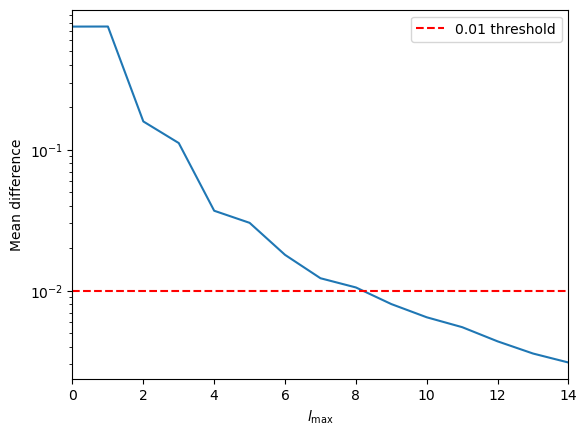

In [160]:
plt.plot(total_diff)
plt.xlabel(r'$l_\mathrm{max}$')
plt.ylabel('Mean difference')
plt.yscale('log')
plt.axhline(y=0.01, color='r', linestyle='--', label='0.01 threshold')
plt.xlim([0, 14])
plt.legend()
plt.show() 

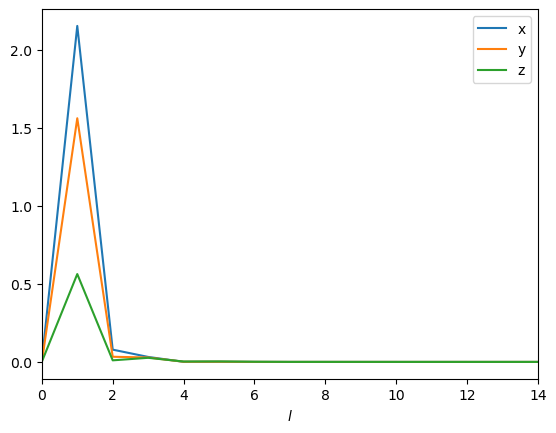

In [161]:
labels = ['x', 'y', 'z']
for i in range(3): 
    plt.plot(m.compute_spectrum(m.coeffs_v[:, i], 15), alpha=1, label=labels[i])
plt.legend()
plt.xlabel(r'$l$')
plt.xlim([0, 14])
plt.show() 

In [79]:
mesh_dict = {
    'spherical': [5, 40],
    'elongated': [27, 33, 42],
    'two_crypts': [20, 32],
    'mickey_mouse': [23, 35],
    'three_crypts': [29],
    'blobby': [28, 38],
}

lookup_dict = {}
for category, values in mesh_dict.items():
    for value in values:
        lookup_dict[value] = category

print(lookup_dict)

colors_dict = {
    'spherical': '#1f77b4',    # Steel blue
    'elongated': '#ff7f0e',    # Bright orange
    'two_crypts': '#2ca02c',   # Forest green
    'mickey_mouse': '#d62728', # Brick red
    'three_crypts': '#9467bd', # Medium purple
    'blobby': '#8c564b'        # Brown
}

{5: 'spherical', 40: 'spherical', 27: 'elongated', 33: 'elongated', 42: 'elongated', 20: 'two_crypts', 32: 'two_crypts', 23: 'mickey_mouse', 35: 'mickey_mouse', 29: 'three_crypts', 28: 'blobby', 38: 'blobby'}


In [80]:
lmax = 15 
spectrums_v = []
spectrums_hks = [] 
t = 1 
for n in lookup_dict.keys(): 
    m = spharm.SpHarm()
    m.load_results(f'sim/{n}')

    eigvals, eigvecs, mass_matrix = eig_decomp(m.v, m.f, k=int(lmax**2))

    hks = [] 
    for t in [0.1, 1, 10]:
        hks.append(np.einsum('i, ji->j', np.exp(-eigvals*t), eigvecs**2))
    hks = np.array(hks).T 

    coeffs_hks = eigvecs.T @ (mass_matrix @ hks)
    coeffs_v = eigvecs.T @ (mass_matrix @ m.v)

    for c in coeffs_v.T: 
        spectrums_v.append(compute_spectrum(c, 15))

    for h in coeffs_hks.T: 
        spectrums_hks.append(compute_spectrum(h, 15))

spectrums_v = np.array(spectrums_v).reshape(len(lookup_dict.keys()), -1)
spectrums_hks = np.array(spectrums_hks).reshape(len(lookup_dict.keys()), -1)

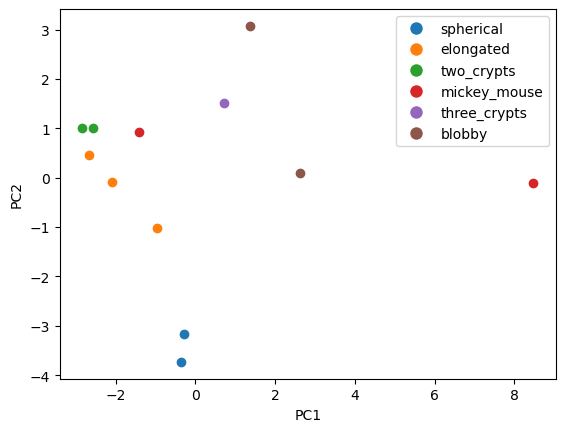

In [133]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

spectrums = np.copy(spectrums_hks)

selector = VarianceThreshold(threshold=1e-10)  # adjust threshold
X_filtered = selector.fit_transform(spectrums)
scaler = StandardScaler()
spectrums = scaler.fit_transform(X_filtered)


pca = PCA(n_components=3)
res = pca.fit(spectrums) 

spectrum_pcs = pca.transform(spectrums)

colors_dict = {
    'spherical': '#1f77b4',    # Steel blue
    'elongated': '#ff7f0e',    # Bright orange
    'two_crypts': '#2ca02c',   # Forest green
    'mickey_mouse': '#d62728', # Brick red
    'three_crypts': '#9467bd', # Medium purple
    'blobby': '#8c564b'        # Brown
}

for (i, n) in enumerate(lookup_dict.keys()):
    plt.plot(spectrum_pcs[i, 0], spectrum_pcs[i, 1], 'o', color=colors_dict[lookup_dict[n]]) 

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor=color, markersize=10, label=category)
                   for category, color in colors_dict.items()]

# Add the legend with all categories
plt.legend(handles=legend_elements, loc='best', frameon=True)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show() 

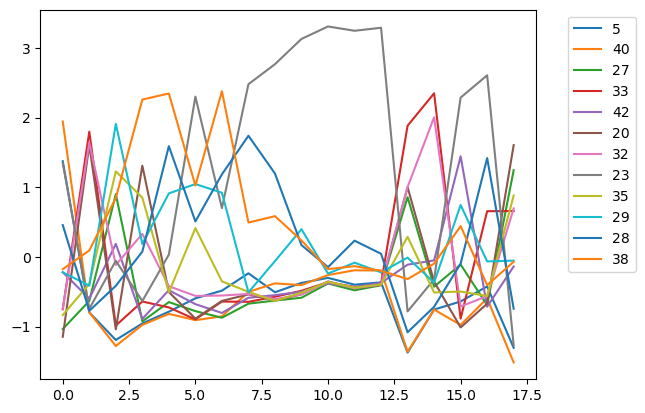

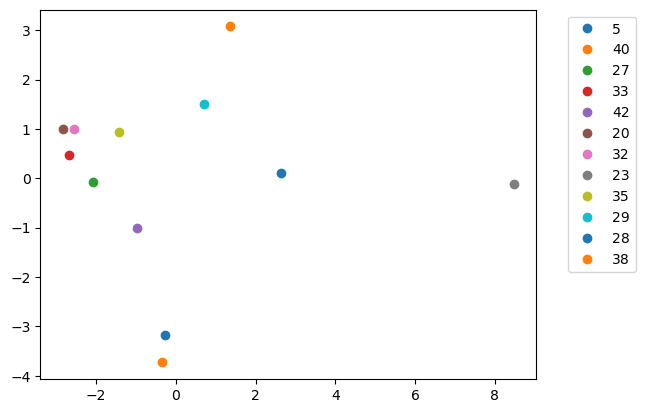

In [134]:
for (i, n) in enumerate(lookup_dict.keys()):
    plt.plot(spectrums[i], label=n)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()  

for (i, n) in enumerate(lookup_dict.keys()):
    plt.plot(spectrum_pcs[i, 0], spectrum_pcs[i, 1], 'o', label=n) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()  

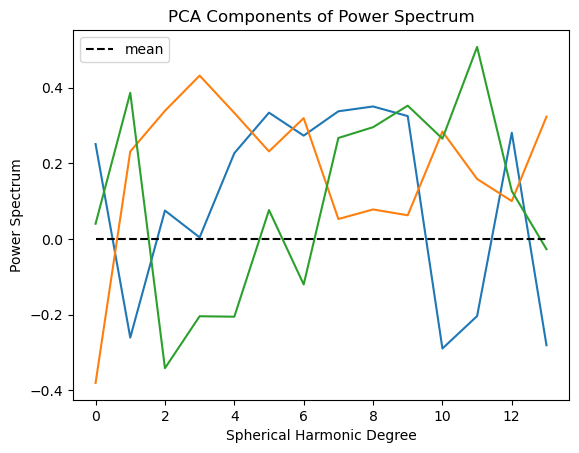

In [128]:
plt.plot(pca.components_[0])
plt.plot(pca.components_[1])
plt.plot(pca.components_[2])
plt.plot(pca.mean_, 'k--', label='mean')
plt.xlabel('Spherical Harmonic Degree')
plt.ylabel('Power Spectrum')
plt.title('PCA Components of Power Spectrum')
plt.legend()
plt.show()